# Converting My CSV Files to DataFrames

In [ ]:
import pandas as pd
import numpy as np
#establishing TMBD as df and others

df_TMDB = pd.read_csv("/content/sample_data/TMDB_movie_dataset_v11.csv")

#Dataset from Kaggle came in 3 parts, will stack together in section line,
#FOR TA: Please update filepath if interested in trying my code.
df_IMDb_1 = pd.read_csv("/content/sample_data/IMDb_Dataset.csv")
df_IMDb_2 = pd.read_csv("/content/sample_data/IMDb_Dataset_2.csv")
df_IMDb_3 = pd.read_csv("/content/sample_data/IMDb_Dataset_3.csv")

#Stacking df on top of each other
df_IMDb_list = pd.concat([df_IMDb_1, df_IMDb_2, df_IMDb_3])

### Merging All Dataframes Based on One Column "Title" and Cleaning

In [ ]:
#Here I am inner joining
merged_df = df_TMDB.merge(
    df_IMDb_list,
    left_on = "title",
    right_on = "Title",
    how = "inner"
)

#Checking and Assessing Columns that I will most likely not need, e.g., homepage link, poster_path, status

merged_df = merged_df.drop((['poster_path','backdrop_path','homepage','status', 'Poster-src']),axis = 1)
display(merged_df.columns)

#Noticed that there are many duplicate of the same title rows, will remove based on first occurence
print("Before clearing duplicates, there was "+str(len(merged_df))+ " movies")
merged_df = merged_df.drop_duplicates(subset=['title'], keep = 'first')
print("After clearing duplicates, there is now "+str(len(merged_df))+ " movies")
merged_df.head()

Index(['id', 'title', 'vote_average', 'vote_count', 'release_date', 'revenue',
       'runtime', 'adult', 'budget', 'imdb_id', 'original_language',
       'original_title', 'overview', 'popularity', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords', 'Title', 'IMDb Rating', 'Year', 'Certificates', 'Genre',
       'Director', 'Star Cast', 'MetaScore', 'Duration (minutes)',
       'Second_Genre', 'Third_Genre'],
      dtype='object')

Before clearing duplicates, there was 15621 movies
After clearing duplicates, there is now 3051 movies


,id,title,vote_average,vote_count,release_date,revenue,runtime,adult,budget,imdb_id,...,IMDb Rating,Year,Certificates,Genre,Director,Star Cast,MetaScore,Duration (minutes),Second_Genre,Third_Genre
0,27205,Inception,8.364,34495,2010-07-15,825532764,148,False,160000000,tt1375666,...,8.8,2010,PG-13,Action,Christopher Nolan,Leonardo DiCaprioJoseph Gordon-LevittElliot Page,74.0,148.0,NaN,NaN
4,157336,Interstellar,8.417,32571,2014-11-05,701729206,169,False,165000000,tt0816692,...,8.7,2014,PG-13,Adventure,Christopher Nolan,Matthew McConaugheyAnne HathawayJessica Chastain,74.0,169.0,NaN,NaN
7,155,The Dark Knight,8.512,30619,2008-07-16,1004558444,152,False,185000000,tt0468569,...,9.0,2008,PG-13,Action,Christopher Nolan,Jonathan NolanChristopher NolanDavid S. Goyer,84.0,152.0,NaN,NaN
9,293660,Deadpool,7.606,28894,2016-02-09,783100000,108,False,58000000,tt1431045,...,8.0,2016,R,Action,Tim Miller,Ryan ReynoldsMorena BaccarinT.J. Miller,65.0,108.0,NaN,NaN
11,299536,Avengers: Infinity War,8.255,27713,2018-04-25,2052415039,149,False,300000000,tt4154756,...,8.4,2018,PG-13,Action,Anthony Russo,Christopher MarkusStephen McFeelyStan Lee,68.0,149.0,NaN,NaN


## Analyzing my dataset, and wondering if I can find a better dataset

Seeing the number of movies dropped from 15k to 3k was a bit discouraging, however, after trying to find a better dataset, I quickly realized that my "one million movie dataset" is riddled with many rows that contained old too old of a movie where even most of its column was left blank. Therefore, I will have to make work with my 3k rows


In [ ]:
#Checking out my df to get a feel of what I'm working with

movie_count_year = merged_df.groupby('Year').size().sort_values()

#Here I see that I have a good amount of rows for each recent year to make an analysis
#(E.g., 2015 has 1269 movies, 2019 has 690...)

# Set option to display all rows
pd.set_option('display.max_rows', None)


print(movie_count_year)



Year
1917      1
1918      1
1921      1
1927      1
1931      1
1934      1
1939      1
1938      1
1958      1
1945      1
1936      2
1935      2
1948      2
1951      2
1943      2
1941      2
1955      2
1949      2
2025      2
1937      3
1953      3
1952      3
1947      3
1944      3
1946      3
1950      4
1942      4
1959      5
1960      5
1957      5
1961      5
1954      5
1967      6
1965      6
1940      6
1956      7
1966      7
1964      7
1979      8
1962      8
1972     10
1963     10
1978     11
1977     11
1971     13
1974     14
1976     14
1970     15
1980     15
1968     15
1982     16
1969     17
1984     17
1983     17
1973     17
1975     19
1986     20
1981     21
1987     22
1991     24
1990     27
1989     27
1988     27
1992     29
1985     30
1996     34
2000     34
1998     39
2001     41
1997     42
1999     43
2003     45
1993     45
2002     46
1995     49
1994     51
2004     54
2005     66
2020     70
2008     71
2006     78
2009     81
2011     85

##Research Question Process

For this portion, I thought a lot about the kind of questions I wanted to investigate regarding movies. However I realized there are so many directions I can go with these kind of information. Since I have information of movie's budget, and their popularity, I think focus more on that area, and see if I have more time at the end of this to try and answer other questions

### Main Research Question
Is there a relationship between a movie's budget and it's popularity or rating?

In order to answer our main research question, I knew I needed to break down the question and focus on general sub questions that will help me understand the full scope of the data.

###Sub-Questions to Help Answer Main Research Question

- Do higher-budget movies tend to recieve higher audience ratings?
- How does popularity differ between low-budget and high-budget films?
- Has this kind of relationship changed over time? (e.g,. before vs after: 2010s, introduction of streaming services, etc)

#Do higher-budget movies tend to recieve higher audience ratings?

/tmp/ipython-input-1757026393.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  analysis_df["log_budget"] = np.log10(analysis_df["budget"])


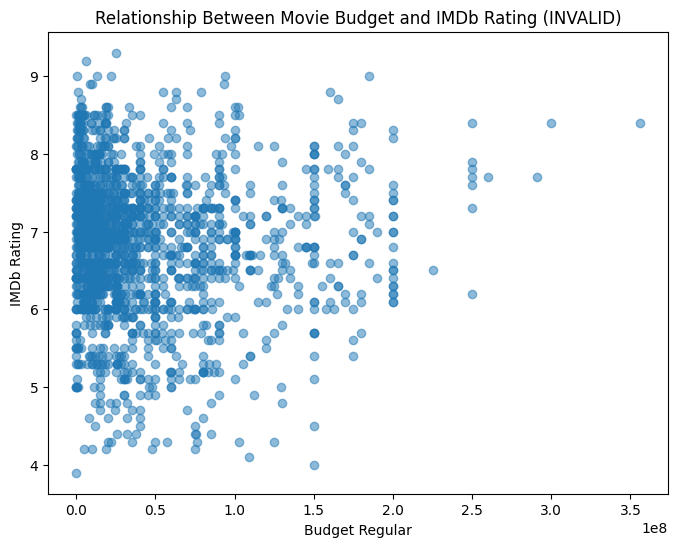

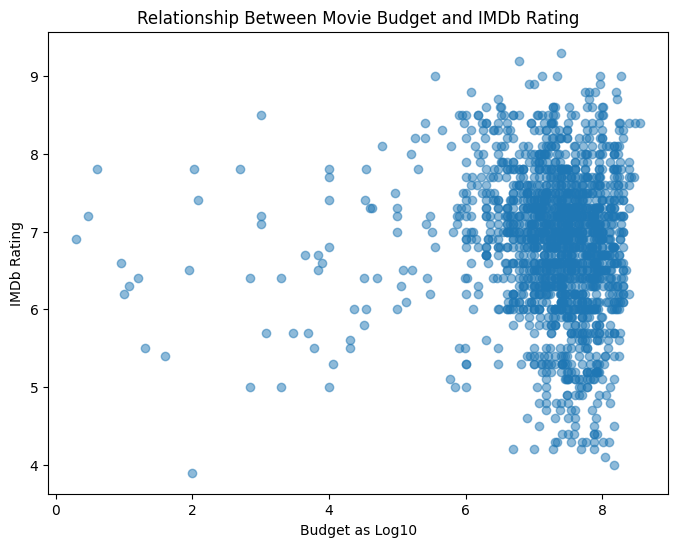

             log_budget  IMDb Rating
log_budget     1.000000    -0.040306
IMDb Rating   -0.040306     1.000000


In [ ]:
import matplotlib.pyplot as plt
#First order of business to clear out any movies that has a budget of less than zero and remove empty ratings cells
#e.g., IMDb Rating and vote_average

analysis_df = merged_df[
    (merged_df["budget"] > 0) &
    (merged_df["IMDb Rating"])
]

#Creating my variable
budget = merged_df["budget"]
rating = merged_df["IMDb Rating"]


#During this process, I got stuck and naively tried representing this normal data as a scatterplot
#and I did not realize that because of budget and ratings, it would cause a mismatch

#INVALID
plt.figure(figsize=(8, 6))
plt.scatter(analysis_df["budget"], analysis_df["IMDb Rating"], alpha=0.5)
plt.xlabel("Budget Regular")
plt.ylabel("IMDb Rating")
plt.title("Relationship Between Movie Budget and IMDb Rating (INVALID)")
#plt.show()



#To fix this issue, I will compress the budget by using logarithmic transformation
#Now instead of 100 million, it will be represented as 8
analysis_df["log_budget"] = np.log10(analysis_df["budget"])

#This scatter plot looks MUCH better
plt.figure(figsize=(8, 6))
plt.scatter(analysis_df["log_budget"], analysis_df["IMDb Rating"], alpha=0.5)
plt.xlabel("Budget as Log10")
plt.ylabel("IMDb Rating")
plt.title("Relationship Between Movie Budget and IMDb Rating")
plt.show()

#Correlation Analysis as scatter plot was a but muddied
print(analysis_df[["log_budget", "IMDb Rating"]].corr())


##**My Observation/Answer for Sub-Question 1:**

For this question, I took all movies budget and their IMDb Rating and placed them on a scatter plot. I felt this is the best method to see if there is a correlation between these two variables. After looking at this scatter plot, I thought it suggested a very slight positive correlation; however, when I looked at the correlation anaysis, to my surprise, it suggested that there's no linear relationship between movie budget and rating (r ~ -0.04).  From looking at the scatter plot a bit more, I do notice that ratings seems to be distributed across ALL budgets levels. Therefore indicating that higher budgets for a movies does not guarantee higher audience ratings!

#Sub-Question 2: How does popularity differ between low-budget and high-budget films?

Now that we see higher budget films doesn't correlate with higher ratings. Let's check to see if groups of budget follow suits as well

budget_group
Low 2 - 15M         23.407217
Medium 15M - 45M    24.639575
High 45M - 356M     53.578730
Name: popularity, dtype: float64
[2.00e+00 1.50e+07 4.50e+07 3.56e+08]


/tmp/ipython-input-185374619.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pop_by_budget = df_q2.groupby("budget_group")["popularity"].mean()


<Axes: title={'center': 'Average Popularity by Budget Group'}, xlabel='budget_group'>

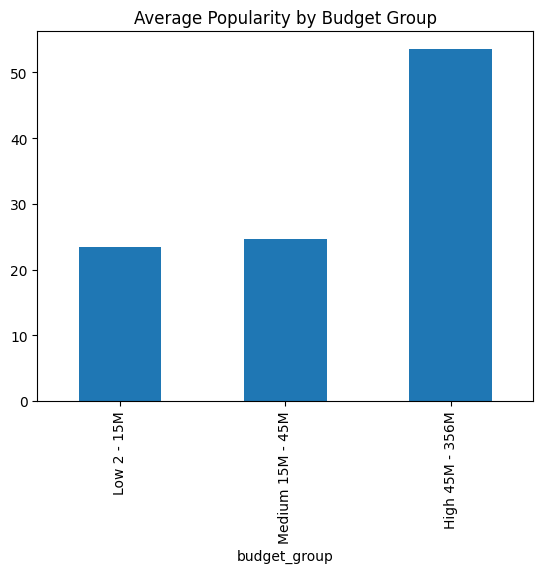

In [ ]:
#Filtering out budgets that are zero
df_q2 = merged_df[merged_df["budget"] > 0].copy()

#Here I am dividing our budget into 3 groups and classed them as Low, Medium, High
df_q2['budget_group'] = pd.qcut(
    df_q2['budget'],
    q = 3,
    labels = ["Low 2 - 15M", "Medium 15M - 45M", "High 45M - 356M"]
)

#Caputuring Mean of each cat
pop_by_budget = df_q2.groupby("budget_group")["popularity"].mean()
print(pop_by_budget)

#I want to see the edges of each bar graph
df_q2["budget_group"], bin_edges = pd.qcut(
    df_q2["budget"],
    q=3,
    retbins=True
)

#From this I see that my data determined
# Low is budget between 2 to 15 million
# Medium is budget between 15 million to 45 million
# High is budget between 45 million to 356 million
print(bin_edges)

#Bar graph Visualization
pop_by_budget.plot(kind="bar", title="Average Popularity by Budget Group")


##What I see from my data and bar graph

- Low Budget(2 - 15M) Popularity Mean is 23.40
- Medium Budget(15M - 45M) Popularity Mean is 24.64
- High Budget(45M - 356M) Popularity Mean is 53.58

The first thing I notice is the massive jump from medium average to high average. On average, its more than twice as popular comparing medium to high

Looking at the bar graph, it shows a relationship between movie budget and popularity by grouping movie budget into three quantile-based budget categories. My analysis reveals a difference in popularity among budget groups. In the high budget category, it showed twice the increase in popularity compared to medium and lower budget films. This data suggest that while increased spending does not necessarily equate to higher audience ratings (from our first sub question), it does however strongly associate with greater ability to expose the film existance and gather a much bigger audience.

#Sub Question 3: Has this kind of relationship changed over time? (e.g,. before vs after: 2010s, introduction of streaming services, etc)

decade
Before 60's     42
60's            43
70's            53
80's           133
90's           249
00's           411
10's           588
20's           178
Name: count, dtype: int64


/tmp/ipython-input-2611708366.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("decade")["IMDb Rating"]


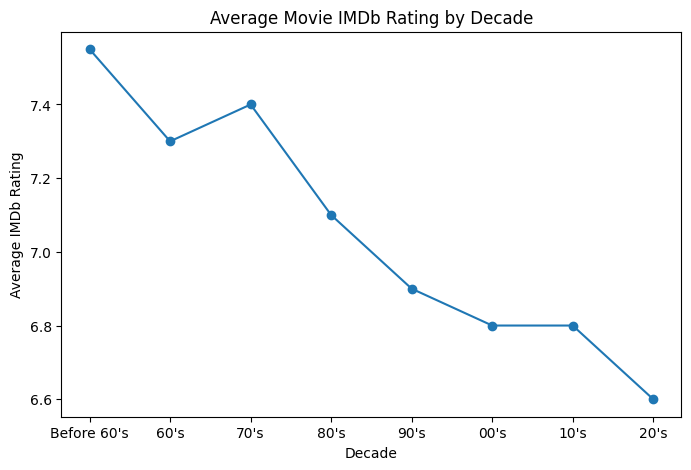

In [ ]:
import matplotlib.pyplot as plt
#For this question, I need to group my films into their corresponding category by decades

#I need to filter out rows that have no IMDb rating to prevent manipulation
q3_df = merged_df[
    (merged_df["budget"] > 0) &
    (merged_df["IMDb Rating"].notna())
].copy()


#I will play with year ranges to see what is the best way to divide them evenly
bins = [0,1960, 1970, 1980, 1990, 2000, 2010,2020,2025]

labels = ["Before 60's", "60's", "70's", "80's", "90's", "00's","10's", "20's"]

q3_df['decade'] = pd.cut(
    q3_df['Year'],
    bins = bins,
    labels = labels,
    right = False
)

#Here, I am happy with this distribution. Even though we had a large drop of movies overall
#We still have plenty of movies per decade (e.g., >= 80 movies per decade)
#Note: I condensed 60's prior to one, Very few films
print(q3_df["decade"].value_counts().sort_index())


#Below is creating the visual
popularity_by_decade = (
    q3_df
    .groupby("decade")["IMDb Rating"]
    .median()
)

plt.figure(figsize=(8, 5))
plt.plot(
    popularity_by_decade.index,
    popularity_by_decade.values,
    marker="o"
)

plt.xlabel("Decade")
plt.ylabel("Average IMDb Rating")
plt.title("Average Movie IMDb Rating by Decade")

plt.show()


